In [1]:
import sys
sys.path.insert(0, r"D:\CODES\Research\neurodiffeq")

In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
# Graph aesthetics settings
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
large = 20; medium = 16; small = 12
colors = ['#66bb6a', '#558ed5', '#dd6a63', '#dcd0ff', '#ffa726', '#8c5eff', '#f44336', '#00bcd4', '#ffc107', '#9c27b0']
text_color = "#404040"

params = {'axes.titlesize': medium,
          'legend.fontsize': small,
          'figure.figsize': (16, 16),
          'axes.labelsize': small,
          'axes.linewidth': 2,
          'xtick.labelsize': small,
          'xtick.color': text_color,
          'ytick.color': text_color,
          'ytick.labelsize': small,
          'axes.edgecolor': text_color,
          'figure.titlesize': small,
          'axes.prop_cycle': cycler(color=colors),
          'axes.titlecolor': text_color,
          'axes.labelcolor': text_color,
         }

plt.rcParams.update(params)

In [4]:
import torch
import numpy as np
import neurodiffeq
import torch.nn as nn
from neurodiffeq import diff      
from neurodiffeq.ode import solve 
from neurodiffeq.conditions import IVP 
from neurodiffeq.networks import FCNN
from neurodiffeq.solvers import Solver1D
from neurodiffeq.generators import Generator1D

C:\Users\laksh\anaconda3\envs\torch\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [5]:
def plot_loss(solver):
    history = solver.metrics_history
    plt.figure(figsize=(8,5))
    plt.plot(np.log10(history['train_loss']), label = 'Train')
    
    # Add axis labels, title and legend for clarity
    plt.title('Loss plot')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_results(solver):
    history = solver.metrics_history
    t_vals = torch.linspace(solver.t_min, solver.t_max, 256).reshape(256)
    u_pred = solver.get_solution()(t_vals, to_numpy=True)
    plt.figure(figsize=(8,5))
    plt.plot(t_vals.cpu().detach().numpy() , u_pred, c = colors[1])
    
    # Add axis labels and title for clarity
    plt.title(f'Neural Network approximation at {len(history["train_loss"])} epochs.')
    plt.xlabel('u')
    plt.ylabel('t')
    plt.grid(True)
    plt.show()

def plot_residuals(solver):
    t_vals = np.linspace(solver.t_min, solver.t_max, 256)
    residuals = solver.get_residuals(t_vals, to_numpy=True)
    plt.figure(figsize=(8,5))
    plt.plot(t_vals, residuals, color=colors[2])
    plt.title(f'Residuals')
    plt.xlabel('t')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.show()

In [6]:
class SineActivation(nn.Module):
    def forward(self, input):
        return torch.sin(input)

## Proper attention

import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, units):
        super(Attention, self).__init__()
        self.units = units
        self.W1 = nn.Linear(units, units)
        self.W2 = nn.Linear(units, units)
        self.V = nn.Linear(units, units)

    def forward(self, values):
        query = self.W1(values.T).reshape(-1, 1)
        keys = self.W2(values.T).reshape(-1, 1)
        attention_weights = torch.matmul(query, keys.transpose(-2, -1))
        attention_weights = F.softmax(attention_weights, dim=1)
        attention_weigths = torch.sum(attention_weights, dim=1)
        #values = self.V(values.T).reshape(-1, 1)
        context_vector = torch.matmul(attention_weights, values)
        return context_vector.T

class ANN(nn.Module):
    def __init__(self, n_input_units=1, attention_units=16, hidden_units=[16,16], actv=nn.Tanh, n_output_units=1):
        super(ANN, self).__init__()
        #self.input_layer = nn.Linear(n_input_units, attention_units)
        self.actv = actv()
        self.attention = Attention(attention_units)
        self.hidden_layers = nn.ModuleList()
        self.hidden_layers.append(self.actv)
        self.hidden_layers.append(nn.Linear(attention_units, hidden_units[0]))
        for i in range(len(hidden_units)-1):
            self.hidden_layers.append(self.actv)
            self.hidden_layers.append(nn.Linear(hidden_units[i], hidden_units[i+1]))
        self.hidden_layers.append(self.actv)
        self.hidden_layers.append(nn.Linear(hidden_units[-1], n_output_units))
        

    def forward(self, x):
        # input_vector = self.input_layer(x)
        # act = self.actv(input_vector)
        context_vector = self.attention(x)
        for layer in self.hidden_layers:
            context_vector = layer(context_vector)#.transpose(-1, 0))
        context_vector = context_vector.T
        return context_vector

In [19]:
## Attention with embedding

import torch
import torch.nn as nn
import torch.nn.functional as F

class Attention(nn.Module):
    def __init__(self, units):
        super(Attention, self).__init__()
        self.units = units
        self.W = nn.Linear(units, units)

    def forward(self, values):
        query = self.W(values.T).reshape(-1, 1)
        keys = self.W(values.T).reshape(-1, 1)
        attention_weights = torch.matmul(query, keys.transpose(-2, -1))
        attention_weights = F.softmax(attention_weights, dim=1)
        attention_weigths = torch.sum(attention_weights, dim=1)
        values = self.W(values.T).reshape(-1, 1)
        context_vector = torch.matmul(attention_weights, values)
        return context_vector.T

class ANN(nn.Module):
    def __init__(self, n_input_units=1, attention_units=16, hidden_units=[16,16], actv=nn.Tanh, n_output_units=1):
        super(ANN, self).__init__()
        #self.input_layer = nn.Linear(n_input_units, attention_units)
        self.actv = actv()
        self.attention = Attention(attention_units)
        self.hidden_layers = nn.ModuleList()
        self.hidden_layers.append(self.actv)
        self.hidden_layers.append(nn.Linear(attention_units, hidden_units[0]))
        for i in range(len(hidden_units)-1):
            self.hidden_layers.append(self.actv)
            self.hidden_layers.append(nn.Linear(hidden_units[i], hidden_units[i+1]))
        self.hidden_layers.append(self.actv)
        self.hidden_layers.append(nn.Linear(hidden_units[-1], n_output_units))
        

    def forward(self, x):
        # input_vector = self.input_layer(x)
        # act = self.actv(input_vector)
        context_vector = self.attention(x)
        for layer in self.hidden_layers:
            context_vector = layer(context_vector)#.transpose(-1, 0))
        context_vector = context_vector.T
        return context_vector

In [20]:
class CustomIVP(IVP):
    def __init__(self, t_0, u_0=None, u_0_prime=None):
        super(IVP, self).__init__()
        self.t_0, self.u_0, self.u_0_prime = t_0, u_0, u_0_prime

    def enforce(self, net, *coordinates):
        r"""Enforces this condition on a network.

        :param net: The network whose output is to be re-parameterized.
        :type net: `torch.nn.Module`
        :param coordinates: Inputs of the neural network.
        :type coordinates: `torch.Tensor`
        :return: The re-parameterized output, where the condition is automatically satisfied.
        :rtype: `torch.Tensor`
        """
        network_output = net(torch.cat(coordinates, dim=0))
        # if `ith_unit` is set, the condition will only be enforced on the i-th output unit
        if self.ith_unit is not None:
            network_output = network_output[:, self.ith_unit].view(-1, 1)
        # parameterize the raw output and return
        return self.parameterize(network_output, coordinates)

    def parameterize(self, output_tensor, t):
        r"""Re-parameterizes outputs such that the Dirichlet/Neumann condition is satisfied.

        - For Dirichlet condition, the re-parameterization is
          :math:`\displaystyle u(t) = u_0 + \left(1 - e^{-(t-t_0)}\right) \mathrm{ANN}(t)`
          where :math:`\mathrm{ANN}` is the neural network.
        - For Neumann condition, the re-parameterization is
          :math:`\displaystyle u(t) = u_0 + (t-t_0) u'_0 + \left(1 - e^{-(t-t_0)}\right)^2 \mathrm{ANN}(t)`
          where :math:`\mathrm{ANN}` is the neural network.

        :param output_tensor: Output of the neural network.
        :type output_tensor: `torch.Tensor`
        :param t: Input to the neural network; i.e., sampled time-points; i.e., independent variables.
        :type t: `torch.Tensor`
        :return: The re-parameterized output of the network.
        :rtype: `torch.Tensor`
        """
        t = torch.cat(t, dim=0)
        if self.u_0_prime is None:
            return self.u_0 + (1 - torch.exp(-t + self.t_0)) * output_tensor
        else:
            return self.u_0 + (t - self.t_0) * self.u_0_prime + ((1 - torch.exp(-t + self.t_0)) ** 2) * output_tensor

In [25]:
def harmonic_oscillator(u, t):
    return [diff(u, t, order=2, shape_check=False) + 16*torch.pi**2*torch.sin(u)]
    # return [u-torch.sin(t)]
init_val_ho = [CustomIVP(t_0=0.0, u_0=0.0, u_0_prime=1.0)]
nets = [ANN(n_input_units=256, attention_units = 256, hidden_units=[32, 32, 32], actv=SineActivation, n_output_units=256)]
t_min = 0
t_max = 1
train_g = Generator1D(256, t_min, t_max , method='equally-spaced-noisy')
valid_g = Generator1D(64, t_min, t_max , method='uniform')

In [26]:
print(nets)

[ANN(
  (actv): SineActivation()
  (attention): Attention(
    (W): Linear(in_features=256, out_features=256, bias=True)
  )
  (hidden_layers): ModuleList(
    (0): SineActivation()
    (1): Linear(in_features=256, out_features=32, bias=True)
    (2): SineActivation()
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): SineActivation()
    (5): Linear(in_features=32, out_features=32, bias=True)
    (6): SineActivation()
    (7): Linear(in_features=32, out_features=256, bias=True)
  )
)]


In [27]:
solver = Solver1D(ode_system=harmonic_oscillator, 
                    conditions=init_val_ho, 
                    t_min=t_min, 
                    t_max=t_max,
                    n_batches_valid=0,
                    train_generator=train_g,
                    valid_generator=valid_g,
                    nets = nets)

Training Progress:   0%|                                                                      | 0/5000 [00:00<…

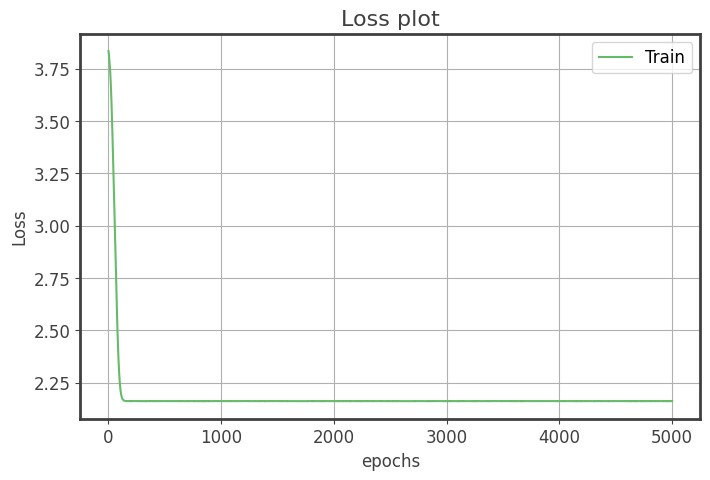

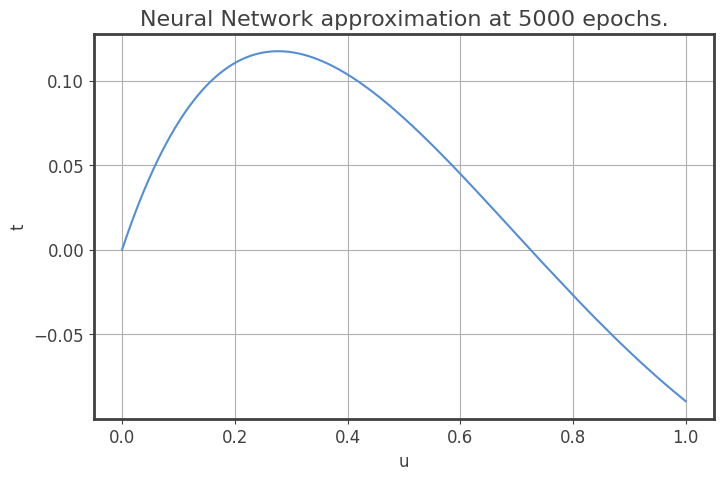

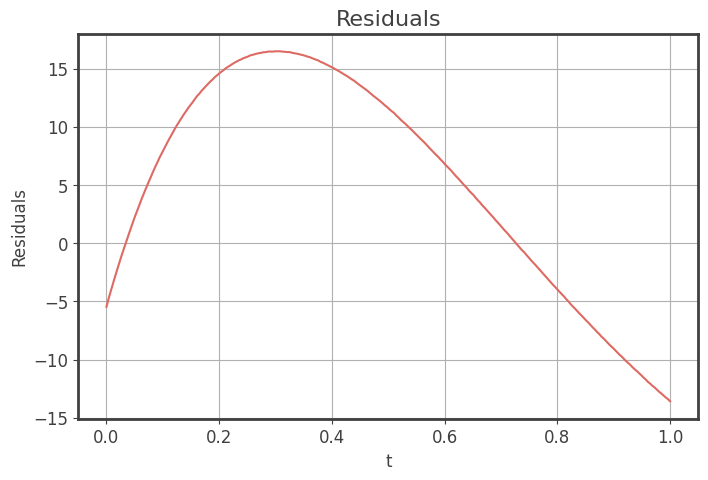

In [28]:
solver.fit(max_epochs=5000)
plot_loss(solver)
plot_results(solver)
plot_residuals(solver)